Domaine :  Dermatology / Skin  

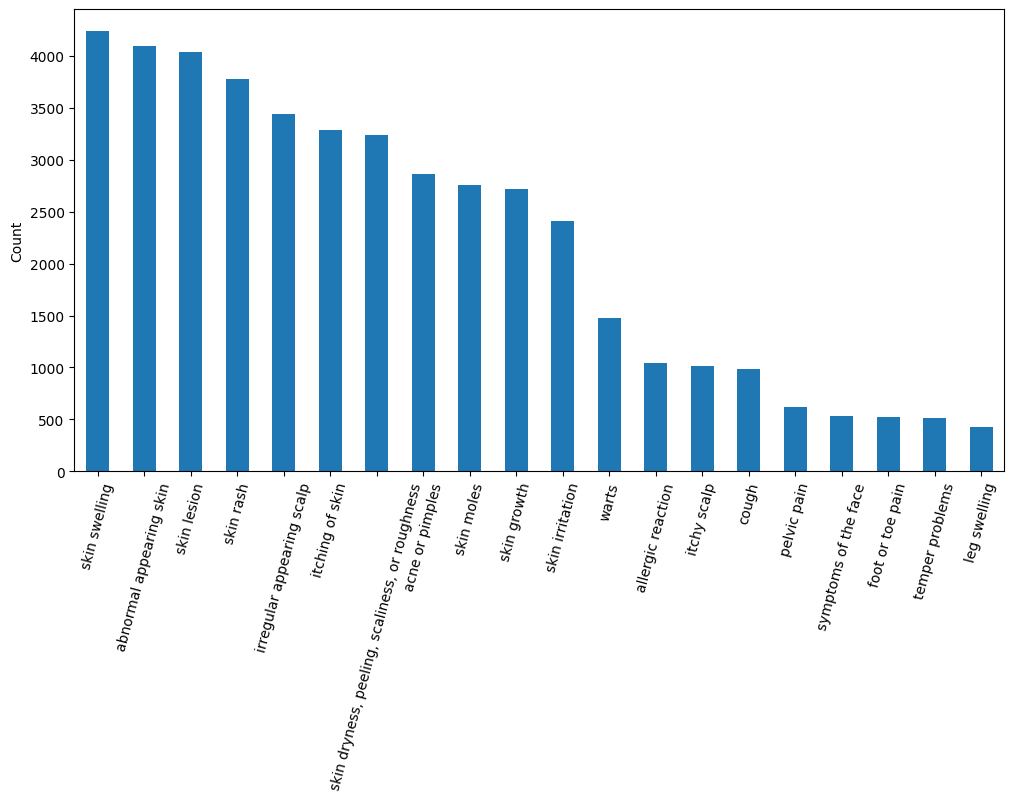

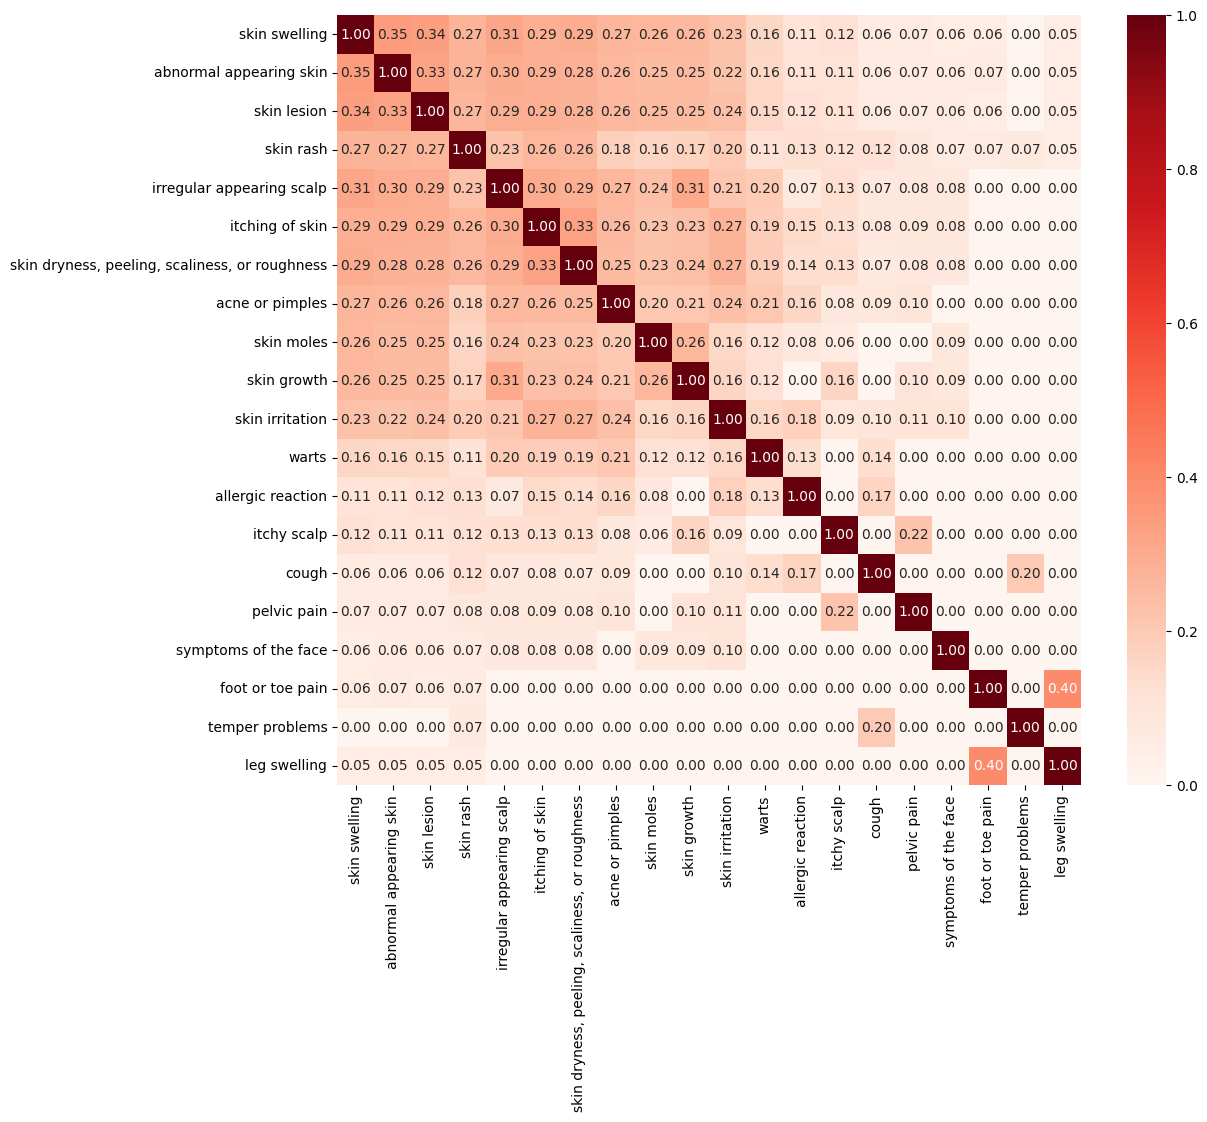

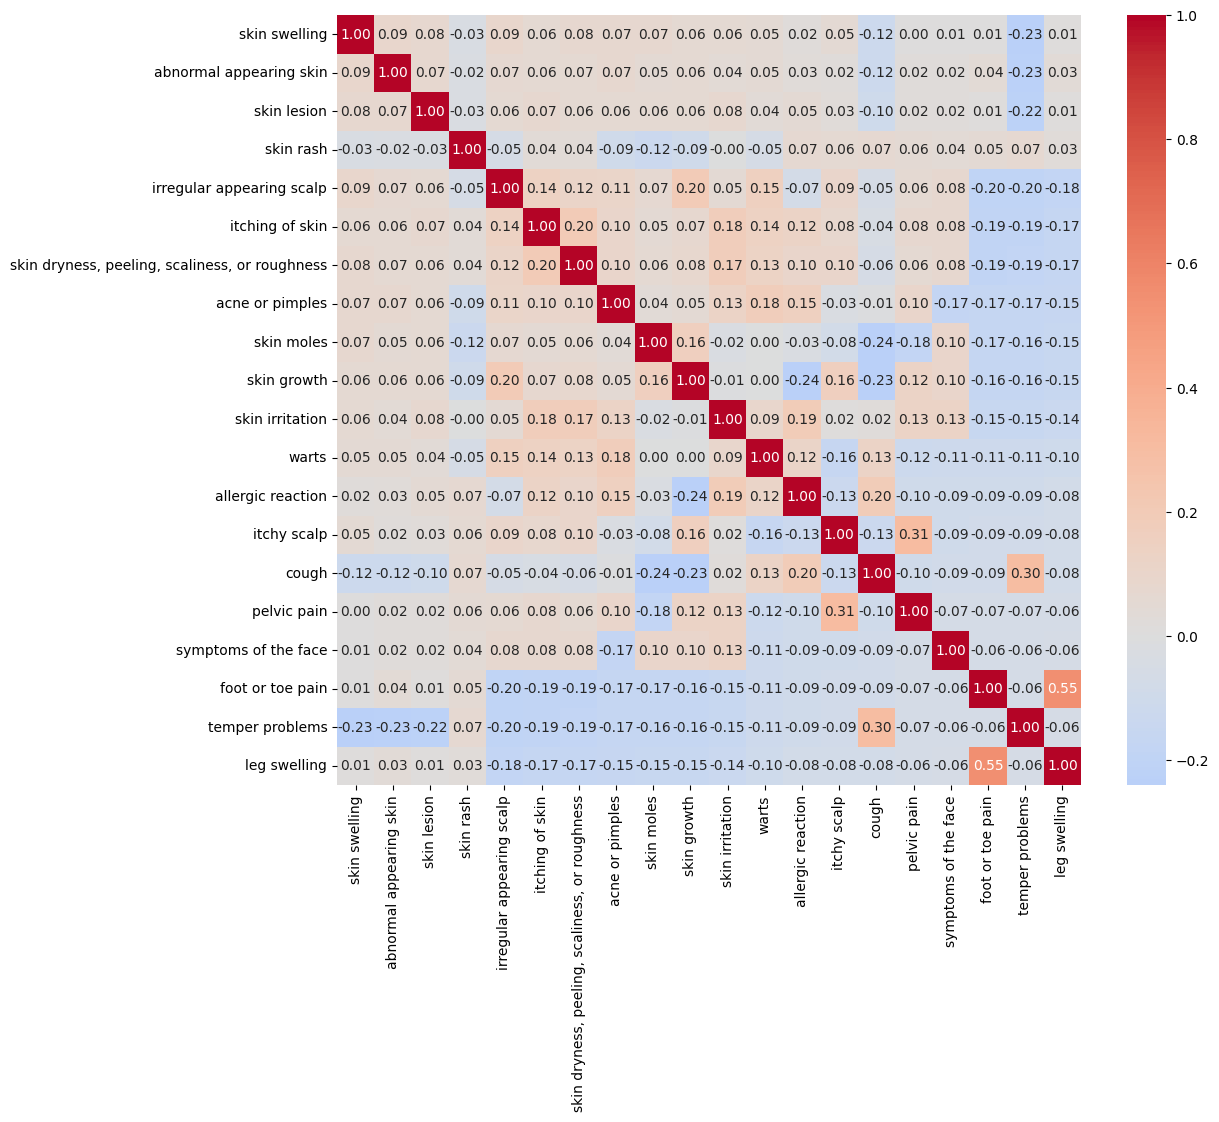

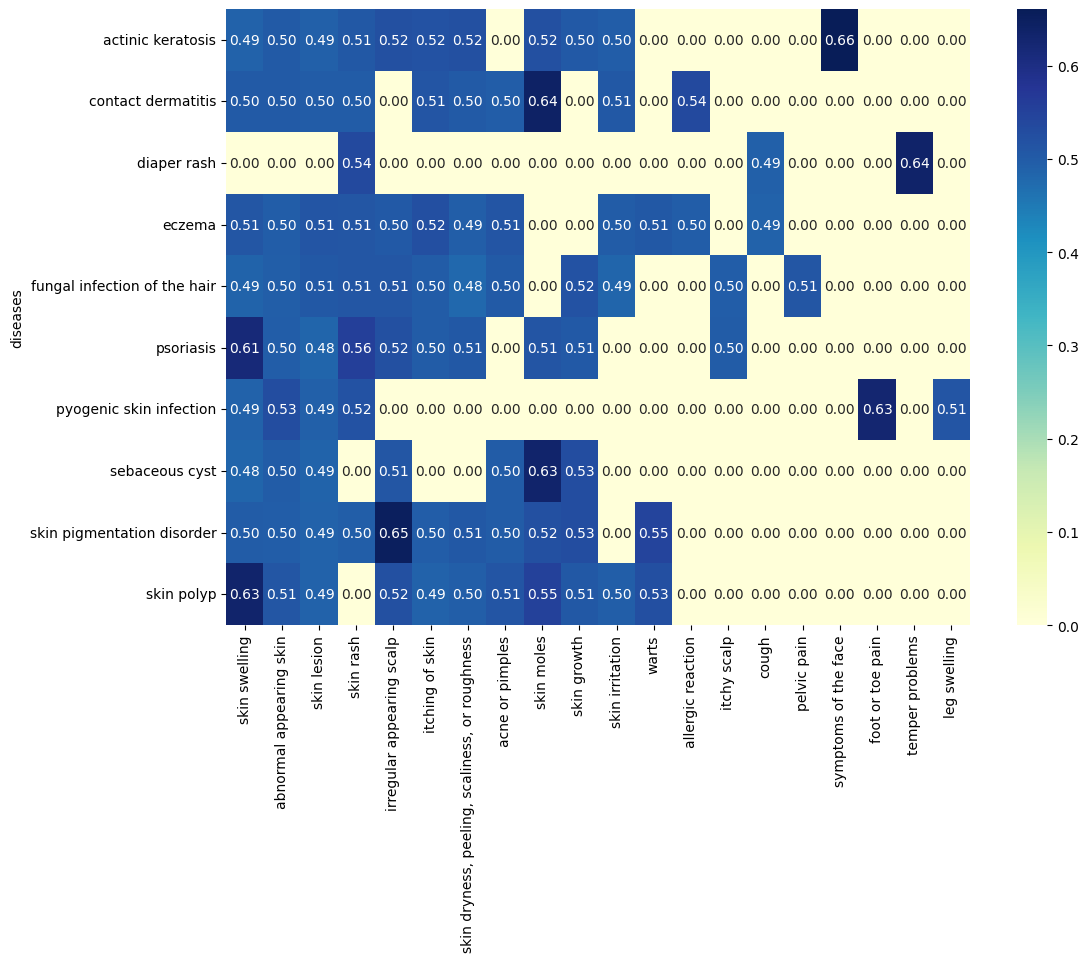

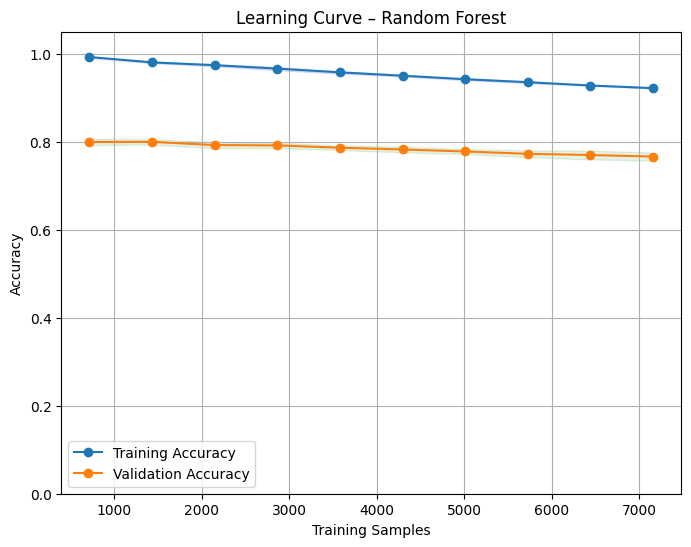

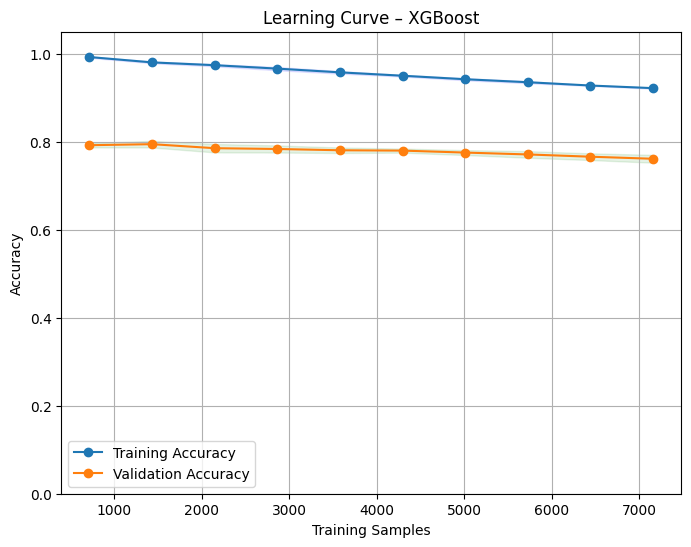

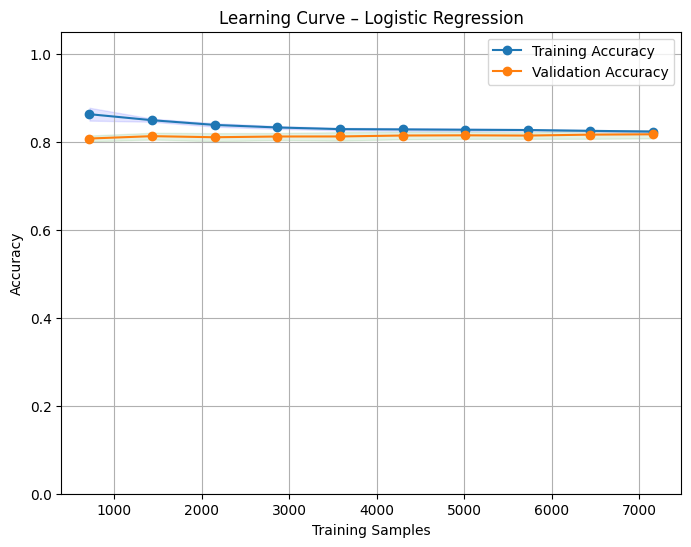

Random Forest Accuracy: 0.7599
                              precision    recall  f1-score   support

           actinic keratosis       0.83      0.71      0.76       162
          contact dermatitis       0.75      0.78      0.77       165
                 diaper rash       1.00      1.00      1.00       162
                      eczema       0.78      0.77      0.78       241
fungal infection of the hair       0.78      0.71      0.74       243
                   psoriasis       0.69      0.76      0.72       165
     pyogenic skin infection       1.00      1.00      1.00       167
              sebaceous cyst       0.98      0.96      0.97       164
  skin pigmentation disorder       0.42      0.45      0.43       161
                  skin polyp       0.42      0.47      0.44       161

                    accuracy                           0.76      1791
                   macro avg       0.77      0.76      0.76      1791
                weighted avg       0.77      0.76      0.

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:44:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.7566
                              precision    recall  f1-score   support

           actinic keratosis       0.79      0.72      0.75       162
          contact dermatitis       0.75      0.76      0.75       165
                 diaper rash       1.00      0.99      1.00       162
                      eczema       0.76      0.78      0.77       241
fungal infection of the hair       0.77      0.72      0.74       243
                   psoriasis       0.70      0.73      0.71       165
     pyogenic skin infection       1.00      1.00      1.00       167
              sebaceous cyst       0.96      0.96      0.96       164
  skin pigmentation disorder       0.45      0.47      0.46       161
                  skin polyp       0.41      0.43      0.42       161

                    accuracy                           0.76      1791
                   macro avg       0.76      0.76      0.76      1791
                weighted avg       0.76      0.76      0.76    

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: 0.8163
                              precision    recall  f1-score   support

           actinic keratosis       0.94      0.72      0.81       162
          contact dermatitis       0.81      0.82      0.82       165
                 diaper rash       1.00      1.00      1.00       162
                      eczema       0.92      0.76      0.83       241
fungal infection of the hair       0.95      0.71      0.81       243
                   psoriasis       0.70      0.82      0.76       165
     pyogenic skin infection       1.00      1.00      1.00       167
              sebaceous cyst       0.99      0.96      0.98       164
  skin pigmentation disorder       0.55      0.71      0.62       161
                  skin polyp       0.52      0.73      0.61       161

                    accuracy                           0.82      1791
                   macro avg       0.84      0.82      0.82      1791
                weighted avg       0.85      0.82  

C:\Users\Admin\AppData\Local\Temp\ipykernel_20928\691903653.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")


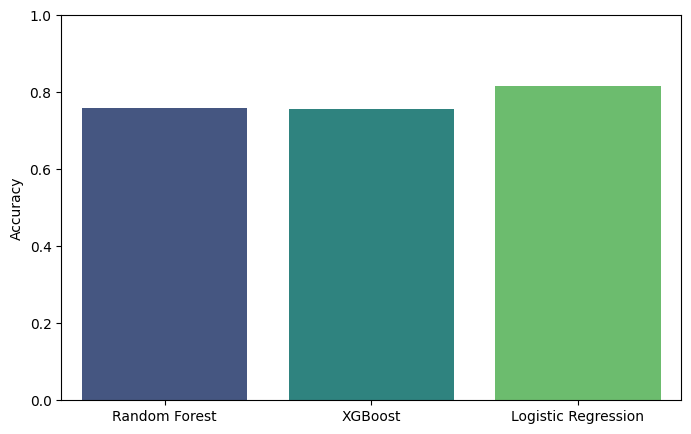

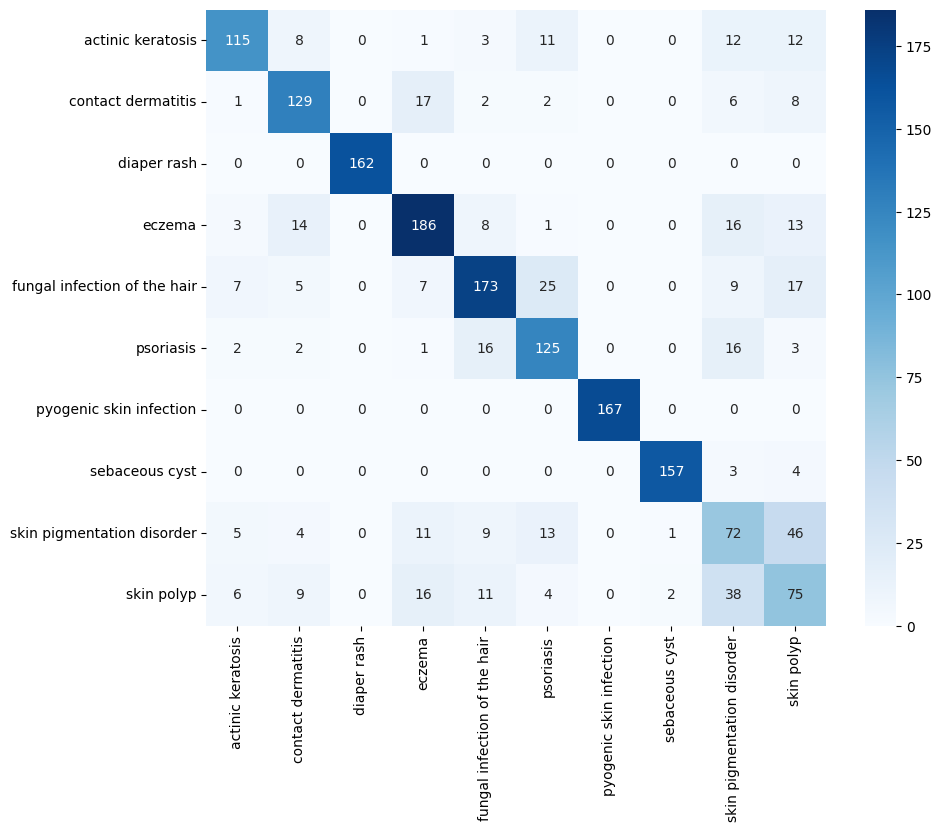

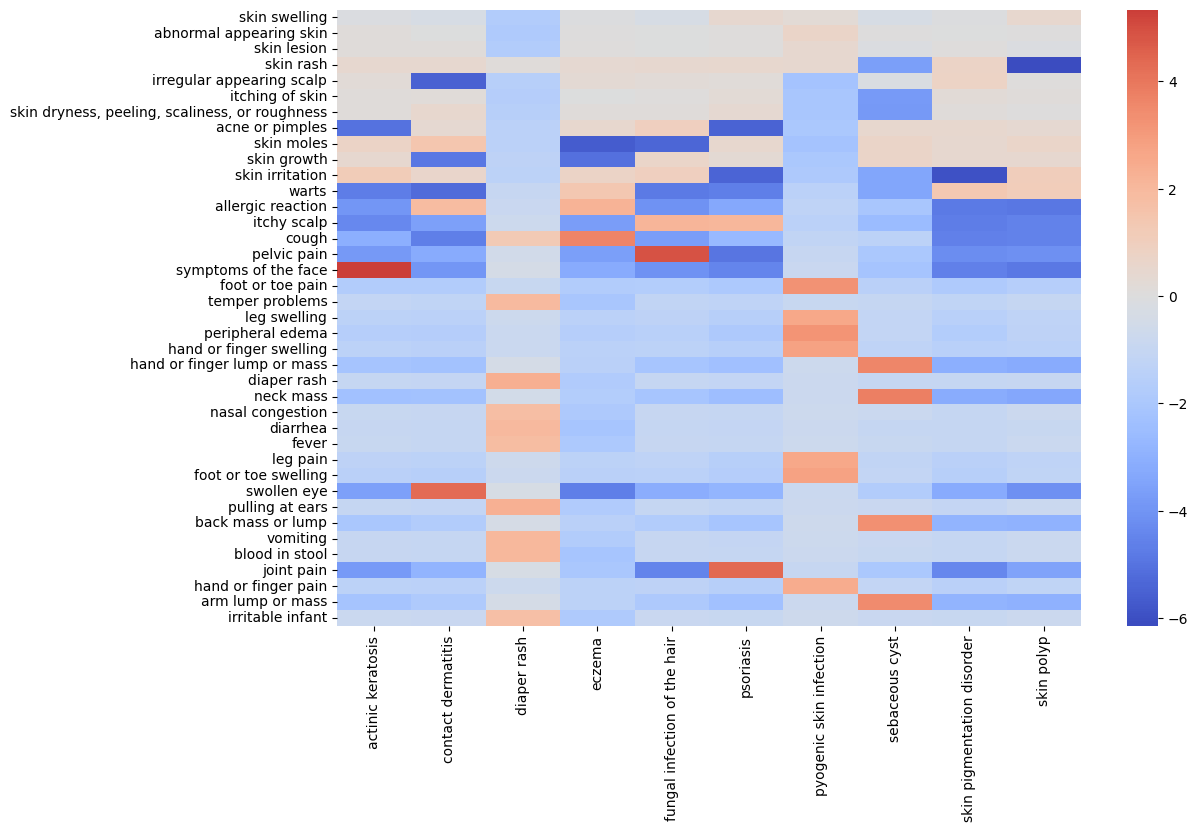

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, jaccard_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

df = pd.read_csv("data/Diseases_and_Symptoms_dataset.csv")

disease_col = "diseases"
symptom_cols = [c for c in df.columns if c != disease_col]

derm_diseases = [
    'psoriasis', 'eczema', 'actinic keratosis',
    'pyogenic skin infection', 'fungal infection of the hair',
    'contact dermatitis', 'skin polyp', 'sebaceous cyst',
    'skin pigmentation disorder', 'diaper rash',
    'dermatitis', 'skin infection'
]

df_derm = df[df[disease_col].isin(derm_diseases)].copy()

symptom_counts = df_derm[symptom_cols].sum().sort_values(ascending=False)
top_symptoms = symptom_counts.head(20).index.tolist()

plt.figure(figsize=(12,6))
symptom_counts.head(20).plot(kind="bar")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.show()

jaccard_matrix = np.zeros((len(top_symptoms), len(top_symptoms)))
for i, s1 in enumerate(top_symptoms):
    for j, s2 in enumerate(top_symptoms):
        jaccard_matrix[i, j] = jaccard_score(df_derm[s1], df_derm[s2])

plt.figure(figsize=(12,10))
sns.heatmap(jaccard_matrix, xticklabels=top_symptoms, yticklabels=top_symptoms, cmap="Reds", annot=True, fmt=".2f")
plt.show()

plt.figure(figsize=(12,10))
sns.heatmap(df_derm[top_symptoms].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.show()

disease_symptom_prob = df_derm.groupby(disease_col)[symptom_cols].mean()
plt.figure(figsize=(12,8))
sns.heatmap(disease_symptom_prob[top_symptoms], cmap="YlGnBu", annot=True, fmt=".2f")
plt.show()

selected_symptoms = symptom_counts[symptom_counts > 0].index.tolist()
X = df_derm[selected_symptoms]
y = df_derm[disease_col]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=500, learning_rate=0.3,
                                 eval_metric="mlogloss", use_label_encoder=False, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", multi_class="ovr")
}

def plot_learning_curve(model, X, y, name):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, train_sizes=np.linspace(0.1,1.0,10),
        scoring="accuracy", n_jobs=-1, shuffle=True, random_state=42
    )
    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label="Training Accuracy")
    plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label="Validation Accuracy")
    plt.fill_between(train_sizes,
                     train_scores.mean(axis=1) - train_scores.std(axis=1),
                     train_scores.mean(axis=1) + train_scores.std(axis=1),
                     alpha=0.1, color='blue')
    plt.fill_between(train_sizes,
                     val_scores.mean(axis=1) - val_scores.std(axis=1),
                     val_scores.mean(axis=1) + val_scores.std(axis=1),
                     alpha=0.1, color='green')
    plt.title(f"Learning Curve – {name}")
    plt.xlabel("Training Samples")
    plt.ylabel("Accuracy")
    plt.ylim(0,1.05)
    plt.grid(True)
    plt.legend()
    plt.show()

for name, model in models.items():
    plot_learning_curve(model, X, y_encoded, name)

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

best_model = models["Random Forest"]
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.show()

lr = models["Logistic Regression"]
coef_df = pd.DataFrame(lr.coef_.T, index=selected_symptoms, columns=le.classes_)
plt.figure(figsize=(12,8))
sns.heatmap(coef_df, cmap="coolwarm", center=0)
plt.show()
